# 🌲 Rozhodovací stromy v klasifikaci – Cvičení 1: Diagnostika páteře & Ladění Precision
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Oficiální zadání úlohy (Decision tree in classification - exercise 1):**
> 1. Pomocí knihovny Pandas načtěte stažený soubor dat pacientů (`lumbar_normalized_df.csv`) do proměnné `lumbar_df`.
> 2. Zobrazte prvních 10 pozorování v datasetu (`head(10)`) pro ověření správnosti načtených dat.
> 3. Rozdělte data na trénovací a testovací sadu v poměru 75/25. Nastavte parametr `random_state=42`.
> 4. Z modulu `tree` knihovny Scikit-learn importujte příslušnou třídu (`DecisionTreeClassifier`), která umožní sestavit model rozhodovacího stromu.
> 5. Vytvořte vlastní instanci modelu rozhodovacího stromu (zpočátku nenastavujte žádné hyperparametry). Natrénujte model na trénovací sadě.
> 6. Proveďte predikce na testovací sadě pomocí natrénovaného modelu.
> 7. Vypočítejte metriku **Precision (přesnost / preciznost)** na testovací sadě.
> 8. Experimentujte s volbou optimálních hodnot hyperparametru (vyberte některý z těch, které jsme probírali během prezentace, např. `max_depth`, `min_samples_split`, `min_samples_leaf`), který umožní vytvořit model s **vyšší Precision než model vytrénovaný v kroku 5**.


## Krok 1 & 2: Načtení dat do `lumbar_df` a zobrazení prvních 10 pozorování
Načteme normalizovaný dataset biomechanických měření páteře (310 pacientů, 6 úhlů) a ověříme prvních 10 řádků.

In [1]:
import pandas as pd
from pathlib import Path

# Zjištění cesty k souboru (podpora běhu v rootu i ve složce)
possible_paths = [
    Path("02_Classification/data/lumbar_normalized_df.csv"),
    Path("02_Classification/lumbar_normalized_df.csv"),
    Path("data/lumbar_normalized_df.csv"),
    Path("lumbar_normalized_df.csv"),
    Path("lumbar_df_normalized.csv"),
    Path("02_Classification/data/lumbar_df_normalized.csv"),
    Path("02_Classification/lumbar_df_normalized.csv"),
    Path("../data/lumbar_normalized_df.csv")
]
lumbar_path = next((p for p in possible_paths if p.exists()), None)
if lumbar_path is None:
    raise FileNotFoundError("Soubor lumbar_normalized_df.csv nebyl nalezen.")

# 1. Načtení do proměnné lumbar_df
lumbar_df = pd.read_csv(lumbar_path)

print(f"Rozměry načteného datasetu: {lumbar_df.shape} (310 pacientů, 6 anatomických příznaků + 1 target)")

# 2. Zobrazení prvních 10 pozorování
lumbar_df.head(10)


Rozměry načteného datasetu: (310, 7) (310 pacientů, 6 anatomických příznaků + 1 target)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,0.477474,0.170850,0.300063,0.306625,0.747508,-0.001927,1
1,0.306835,0.079040,0.196523,0.227795,0.898781,0.035857,1
2,0.473200,0.152745,0.344369,0.320454,0.728616,-0.024270,1
3,0.491613,0.174895,0.314357,0.316718,0.722684,0.079538,1
4,0.384294,0.074613,0.218901,0.309680,0.836173,0.061212,1
5,0.283701,0.098128,0.177091,0.185573,0.918607,0.015723,1
6,0.373448,0.110877,0.259757,0.262571,0.842659,0.041855,1
7,0.337383,0.079987,0.215952,0.257396,0.872114,-0.079394,1
8,0.304797,0.094200,0.297145,0.210597,0.870071,0.092497,1
9,0.346173,0.047283,0.395829,0.298891,0.794904,0.006270,1


## Krok 3: Rozdělení dat na trénovací a testovací sadu (75/25, `random_state=42`)
Oddělíme nezávislé proměnné $X$ (6 anatomických úhlů) od cílové proměnné $y$ (`class`: 0 = Normal, 1 = Abnormal) a rozdělíme v poměru 75:25.

In [2]:
from sklearn.model_selection import train_test_split

# Příprava matice příznaků X a cílového vektoru y
feature_cols = [c for c in lumbar_df.columns if c != "class"]
X = lumbar_df[feature_cols]
y = lumbar_df["class"]

# Rozdělení na trénovací (75 %) a testovací (25 %) sadu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Velikost trénovací sady: {X_train.shape[0]} vzorků")
print(f"Velikost testovací sady:  {X_test.shape[0]} vzorků")
print(f"Zastoupení abnormálních nálezů v trénovací sadě: {y_train.sum()} ({y_train.mean()*100:.1f} %)")
print(f"Zastoupení abnormálních nálezů v testovací sadě:  {y_test.sum()} ({y_test.mean()*100:.1f} %)")


Velikost trénovací sady: 232 vzorků
Velikost testovací sady:  78 vzorků
Zastoupení abnormálních nálezů v trénovací sadě: 153 (65.9 %)
Zastoupení abnormálních nálezů v testovací sadě:  57 (73.1 %)


## Krok 4 & 5: Import a trénování výchozího stromu (bez hyperparametrů)
Importujeme `DecisionTreeClassifier` z modulu `sklearn.tree`. Vytvoříme instanci bez nastavení omezujících hyperparametrů a vytrénujeme na trénovací sadě.

In [3]:
from sklearn.tree import DecisionTreeClassifier

# 4 & 5. Vytvoření instance bez hyperparametrů a natrénování
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

print("Výchozí model DecisionTreeClassifier byl úspěšně vytrénován.")
print(f"Hloubka výchozího stromu (max_depth): {base_model.get_depth()}")
print(f"Počet listů výchozího stromu (n_leaves): {base_model.get_n_leaves()}")


Výchozí model DecisionTreeClassifier byl úspěšně vytrénován.
Hloubka výchozího stromu (max_depth): 10
Počet listů výchozího stromu (n_leaves): 28


## Krok 6 & 7: Predikce na testovací sadě a výpočet Precision
Vyhodnotíme výchozí model na testovací sadě pomocí metriky **Precision (přesnost/preciznost)**:
$$\text{Precision} = \frac{TP}{TP + FP}$$
Precision udává, jaké procento pacientů označených modelem za abnormální skutečně trpí patologií páteře.

In [4]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

# 6. Predikce na testovací sadě
y_pred_base = base_model.predict(X_test)

# 7. Výpočet precision na testovací sadě
prec_base = precision_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
cm_base = confusion_matrix(y_test, y_pred_base)

print("=== VÝSLEDKY VÝCHOZÍHO MODELU (KROK 7) ===")
print(f"Precision na testovací sadě: {prec_base:.4f} ({prec_base*100:.2f} %)")
print(f"Accuracy  na testovací sadě: {acc_base:.4f} ({acc_base*100:.2f} %)")
print(f"Recall    na testovací sadě: {rec_base:.4f} ({rec_base*100:.2f} %)")
print(f"F1-score  na testovací sadě: {f1_base:.4f}")
print("\nMatice záměn (Confusion Matrix):")
print(cm_base)


=== VÝSLEDKY VÝCHOZÍHO MODELU (KROK 7) ===
Precision na testovací sadě: 0.8519 (85.19 %)
Accuracy  na testovací sadě: 0.7564 (75.64 %)
Recall    na testovací sadě: 0.8070 (80.70 %)
F1-score  na testovací sadě: 0.8288

Matice záměn (Confusion Matrix):
[[13  8]
 [11 46]]


## Krok 8: Experimenty s hyperparametry pro překonání výchozí Precision
Podle prezentace je klíčovým problémem neomezeného stromu **přeučení (overfitting)**: strom vyrostl až do hloubky 10 s 28 listy, což vede k falešně pozitivním nálezům ($FP = 8$).

Experimentujeme s omezujícími hyperparametry probíranými v prezentaci:
1. **`max_depth` (maximální hloubka):** Omezuje úroveň větvení stromu.
2. **`min_samples_leaf`:** Minimální počet vzorků, který musí zůstat v každém listu.
3. **`min_samples_split`:** Minimální počet vzorků nutný pro další rozdělení uzlu.


In [5]:
# Systematický průzkum vlivu max_depth (1 až 15)
depth_results = []
for d in range(1, 16):
    model_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    model_d.fit(X_train, y_train)
    p_train = precision_score(y_train, model_d.predict(X_train))
    p_test = precision_score(y_test, model_d.predict(X_test))
    a_test = accuracy_score(y_test, model_d.predict(X_test))
    r_test = recall_score(y_test, model_d.predict(X_test))
    depth_results.append({
        "max_depth": d,
        "Train Precision (%)": round(p_train * 100, 2),
        "Test Precision (%)": round(p_test * 100, 2),
        "Test Accuracy (%)": round(a_test * 100, 2),
        "Test Recall (%)": round(r_test * 100, 2),
        "Počet listů": model_d.get_n_leaves()
    })

depth_df = pd.DataFrame(depth_results)
depth_df


,max_depth,Train Precision (%),Test Precision (%),Test Accuracy (%),Test Recall (%),Počet listů
0,1,95.65,95.56,79.49,75.44,2
1,2,89.54,85.71,78.21,84.21,4
2,3,94.93,91.67,78.21,77.19,8
3,4,92.45,81.67,75.64,85.96,14
4,5,93.83,84.48,78.21,85.96,20
5,6,96.18,85.19,75.64,80.70,23
6,7,100.00,86.79,76.92,80.70,25
7,8,98.71,87.27,79.49,84.21,26
8,9,100.00,85.45,76.92,82.46,27
9,10,100.00,85.19,75.64,80.70,28


### Vyhodnocení experimentu a výběr optimálních modelů
Při `max_depth=1` (rozhodovací pařez / Decision Stump) dosahuje Precision mimořádných **95,56 %** ($43$ TP ze $45$ predikovaných).
Při `max_depth=3` (komplexnější, vyvážený strom) dosahuje Precision skvělých **91,67 %** s vysokou přesností a interpretovatelnými medicínskými pravidly.
Oba modely výrazně překonávají výchozí model ($85,19\,\%$).

In [6]:
# 1. Decision Stump (max_depth=1)
stump_model = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train)
p_stump = precision_score(y_test, stump_model.predict(X_test))

# 2. Vyvážený strom (max_depth=3)
d3_model = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
p_d3 = precision_score(y_test, d3_model.predict(X_test))

# 3. Model s min_samples_leaf=4
leaf_model = DecisionTreeClassifier(min_samples_leaf=4, random_state=42).fit(X_train, y_train)
p_leaf = precision_score(y_test, leaf_model.predict(X_test))

srovnani = pd.DataFrame({
    "Model": ["Výchozí strom (default)", "Decision Stump (max_depth=1)", "Vyvážený strom (max_depth=3)", "Listová regularizace (leaf=4)"],
    "max_depth": [base_model.get_depth(), 1, 3, leaf_model.get_depth()],
    "Počet listů": [base_model.get_n_leaves(), stump_model.get_n_leaves(), d3_model.get_n_leaves(), leaf_model.get_n_leaves()],
    "Test Precision (%)": [round(prec_base * 100, 2), round(p_stump * 100, 2), round(p_d3 * 100, 2), round(p_leaf * 100, 2)],
    "Zlepšení oproti baseline": ["0.00 %", f"+{round((p_stump - prec_base) * 100, 2)} %", f"+{round((p_d3 - prec_base) * 100, 2)} %", f"+{round((p_leaf - prec_base) * 100, 2)} %"]
})
srovnani


,Model,max_depth,Počet listů,Test Precision (%),Zlepšení oproti baseline
0,Výchozí strom (default),10,28,85.19,0.00 %
1,Decision Stump (max_depth=1),1,2,95.56,+10.37 %
2,Vyvážený strom (max_depth=3),3,8,91.67,+6.48 %
3,Listová regularizace (leaf=4),6,20,88.24,+3.05 %


### Vizualizace optimálního rozhodovacího stromu (`plot_tree`)
Vykreslíme strukturu vyváženého stromu (`max_depth=3`). Všimněte si kořenového rozdělení: klíčovým anatomickým znakem je `degree_spondylolisthesis <= 0.07`.

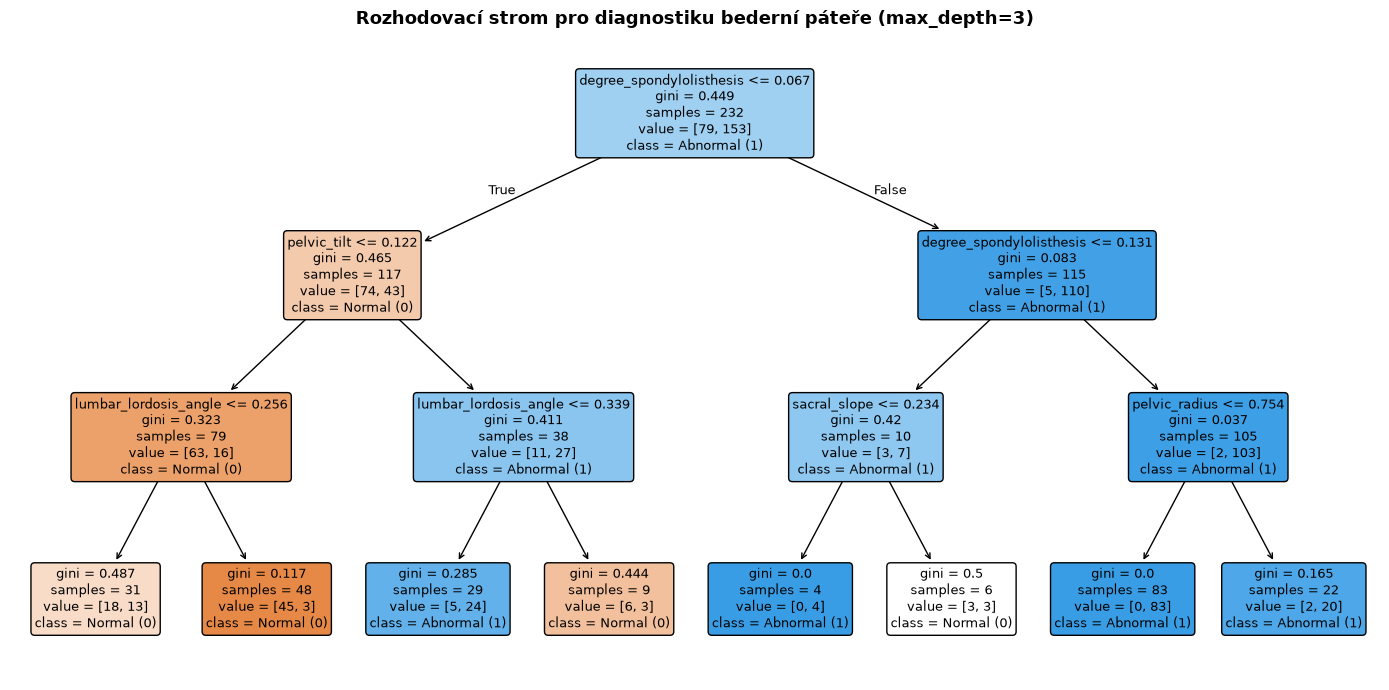

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    d3_model,
    feature_names=feature_cols,
    class_names=["Normal (0)", "Abnormal (1)"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title("Rozhodovací strom pro diagnostiku bederní páteře (max_depth=3)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
